<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/12_chicago_crime_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/Crimes in Boston/crime.csv', encoding='latin1')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,NaN,2018-09-02 13:00:00,2018,9,Sunday,13,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)"
1,I182070943,1402,Vandalism,VANDALISM,C11,347,NaN,2018-08-21 00:00:00,2018,8,Tuesday,0,Part Two,HECLA ST,42.306821,-71.060300,"(42.30682138, -71.06030035)"
2,I182070941,3410,Towed,TOWED MOTOR VEHICLE,D4,151,NaN,2018-09-03 19:27:00,2018,9,Monday,19,Part Three,CAZENOVE ST,42.346589,-71.072429,"(42.34658879, -71.07242943)"
3,I182070940,3114,Investigate Property,INVESTIGATE PROPERTY,D4,272,NaN,2018-09-03 21:16:00,2018,9,Monday,21,Part Three,NEWCOMB ST,42.334182,-71.078664,"(42.33418175, -71.07866441)"
4,I182070938,3114,Investigate Property,INVESTIGATE PROPERTY,B3,421,NaN,2018-09-03 21:05:00,2018,9,Monday,21,Part Three,DELHI ST,42.275365,-71.090361,"(42.27536542, -71.09036101)"


In [5]:
df.shape

(319073, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319073 entries, 0 to 319072
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   INCIDENT_NUMBER      319073 non-null  object 
 1   OFFENSE_CODE         319073 non-null  int64  
 2   OFFENSE_CODE_GROUP   319073 non-null  object 
 3   OFFENSE_DESCRIPTION  319073 non-null  object 
 4   DISTRICT             317308 non-null  object 
 5   REPORTING_AREA       319073 non-null  object 
 6   SHOOTING             1019 non-null    object 
 7   OCCURRED_ON_DATE     319073 non-null  object 
 8   YEAR                 319073 non-null  int64  
 9   MONTH                319073 non-null  int64  
 10  DAY_OF_WEEK          319073 non-null  object 
 11  HOUR                 319073 non-null  int64  
 12  UCR_PART             318983 non-null  object 
 13  STREET               308202 non-null  object 
 14  Lat                  299074 non-null  float64
 15  Long             

In [7]:
df.describe()

,OFFENSE_CODE,YEAR,MONTH,HOUR,Lat,Long
count,319073.000000,319073.000000,319073.000000,319073.000000,299074.000000,299074.000000
mean,2317.546956,2016.560586,6.609719,13.118205,42.214381,-70.908272
std,1185.285543,0.996344,3.273691,6.294205,2.159766,3.493618
min,111.000000,2015.000000,1.000000,0.000000,-1.000000,-71.178674
25%,1001.000000,2016.000000,4.000000,9.000000,42.297442,-71.097135
50%,2907.000000,2017.000000,7.000000,14.000000,42.325538,-71.077524
75%,3201.000000,2017.000000,9.000000,18.000000,42.348624,-71.062467
max,3831.000000,2018.000000,12.000000,23.000000,42.395042,-1.000000


**2. Data Cleaning**

In [8]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
SHOOTING,318054
Lat,19999
Long,19999
STREET,10871
DISTRICT,1765
UCR_PART,90
INCIDENT_NUMBER,0
OFFENSE_CODE_GROUP,0
OFFENSE_CODE,0
YEAR,0


In [9]:
# Convert OCCURRED_ON_DATE to datetime
df['OCCURRED_ON_DATE'] = pd.to_datetime(df['OCCURRED_ON_DATE'])
df[['OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR']].head()

,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR
0,2018-09-02 13:00:00,2018,9,Sunday,13
1,2018-08-21 00:00:00,2018,8,Tuesday,0
2,2018-09-03 19:27:00,2018,9,Monday,19
3,2018-09-03 21:16:00,2018,9,Monday,21
4,2018-09-03 21:05:00,2018,9,Monday,21


In [10]:
# SHOOTING column is mostly null (only marked 'Y' when true) - fill with 'N'
df['SHOOTING'] = df['SHOOTING'].fillna('N')
df['SHOOTING'].value_counts()

,count
SHOOTING,
N,318054
Y,1019


In [11]:
# DISTRICT has some missing values - fill with 'Unknown'
df['DISTRICT'] = df['DISTRICT'].fillna('Unknown')

# UCR_PART, STREET - fill with 'Unknown' too
df['UCR_PART'] = df['UCR_PART'].fillna('Unknown')
df['STREET'] = df['STREET'].fillna('Unknown')

In [12]:
# Lat/Long missing - keep rows for time/category analysis, we'll filter for geospatial section separately
print("Missing Lat:", df['Lat'].isnull().sum())
print("Missing Long:", df['Long'].isnull().sum())

# Some datasets use 0.0 or -1.0 as placeholder for missing coordinates - check for that too
print("Lat == 0:", (df['Lat'] == 0).sum())
print("Lat == -1:", (df['Lat'] == -1).sum())

Missing Lat: 19999
Missing Long: 19999
Lat == 0: 0
Lat == -1: 745


In [13]:
# Treat placeholder coordinates as missing
df.loc[(df['Lat'] == -1) | (df['Lat'] == 0), 'Lat'] = np.nan
df.loc[(df['Long'] == -1) | (df['Long'] == 0), 'Long'] = np.nan

In [14]:
# Check duplicates
df = df.drop_duplicates()
df.shape

(319050, 17)

In [15]:
# Simplify OFFENSE_CODE_GROUP - group rare categories into 'Other'
top_offenses = df['OFFENSE_CODE_GROUP'].value_counts().head(15).index
df['offense_simplified'] = df['OFFENSE_CODE_GROUP'].apply(lambda x: x if x in top_offenses else 'Other')
df['offense_simplified'].value_counts()

,count
offense_simplified,
Other,93602
Motor Vehicle Accident Response,37132
Larceny,25935
Medical Assistance,23540
Investigate Person,18749
Drug Violation,16545
Simple Assault,15826
Vandalism,15414
Verbal Disputes,13099


**3. Univariate Analysis**

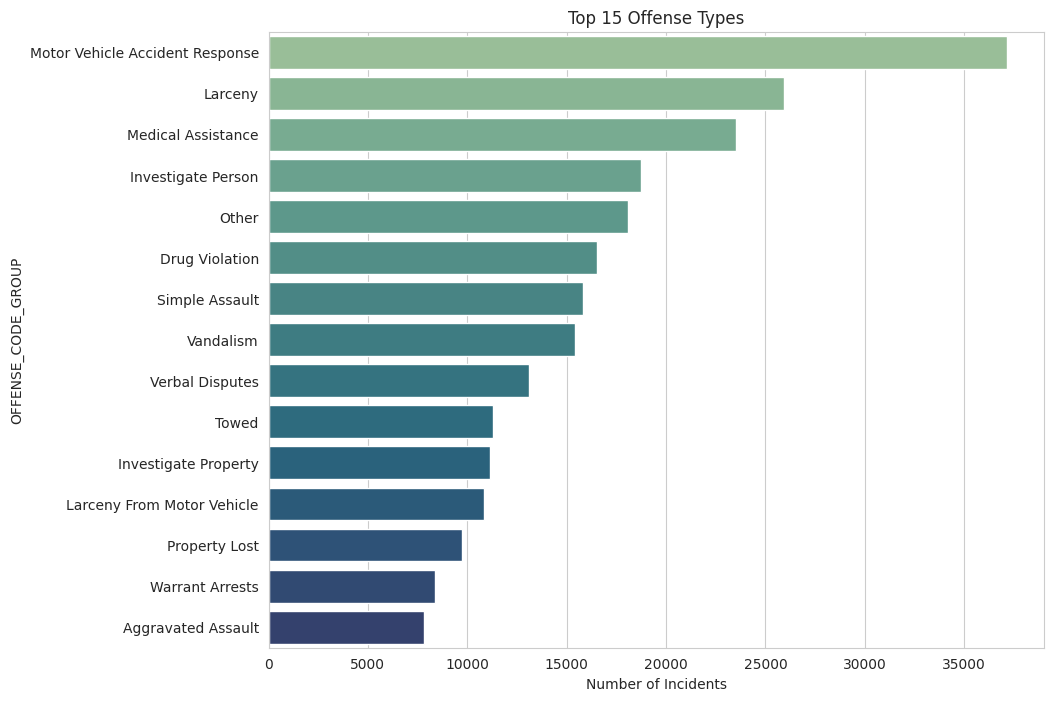

In [16]:
# Top 15 offense types
top_offense_counts = df['OFFENSE_CODE_GROUP'].value_counts().head(15)

plt.figure(figsize=(10,8))
sns.barplot(x=top_offense_counts.values, y=top_offense_counts.index, hue=top_offense_counts.index, palette='crest', legend=False)
plt.title('Top 15 Offense Types')
plt.xlabel('Number of Incidents')
plt.show()

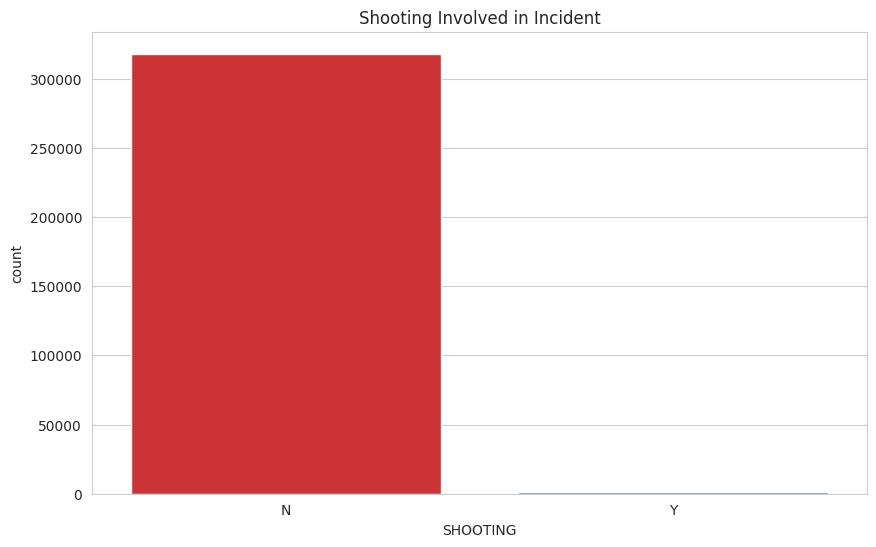

In [17]:
# Shooting incidents proportion
sns.countplot(data=df, x='SHOOTING', hue='SHOOTING', palette='Set1', legend=False)
plt.title('Shooting Involved in Incident')
plt.show()

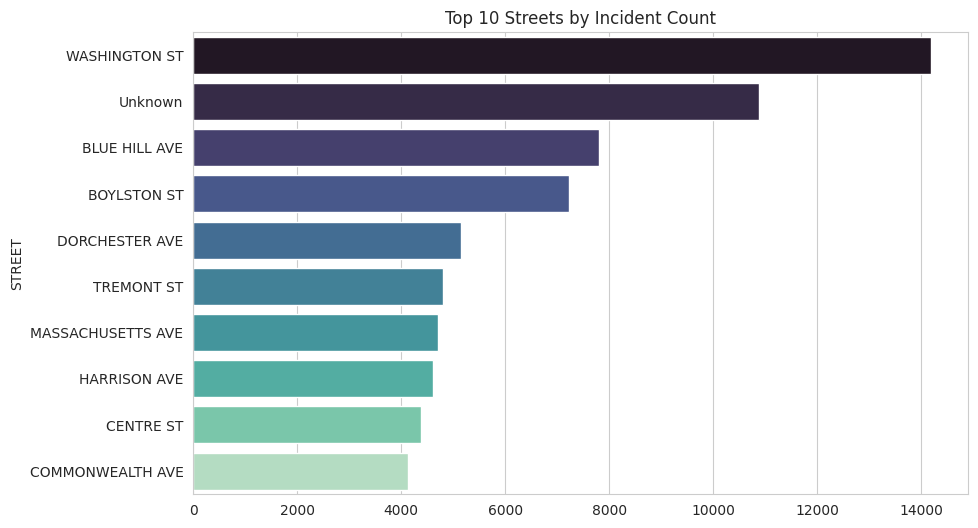

In [18]:
# Top 10 locations (street)
top_streets = df['STREET'].value_counts().head(10)

sns.barplot(x=top_streets.values, y=top_streets.index, hue=top_streets.index, palette='mako', legend=False)
plt.title('Top 10 Streets by Incident Count')
plt.show()

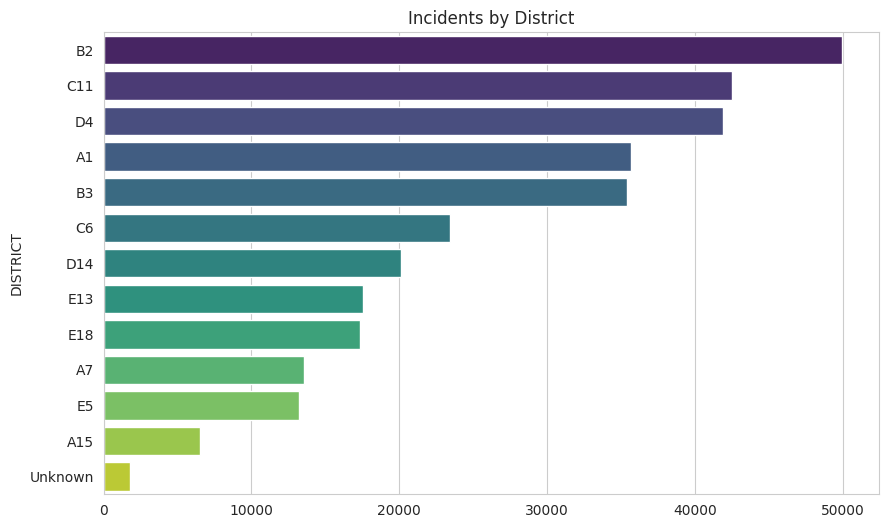

In [19]:
# Crimes by district
district_counts = df['DISTRICT'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=district_counts.values, y=district_counts.index, hue=district_counts.index, palette='viridis', legend=False)
plt.title('Incidents by District')
plt.show()

**4. Temporal Analysis**

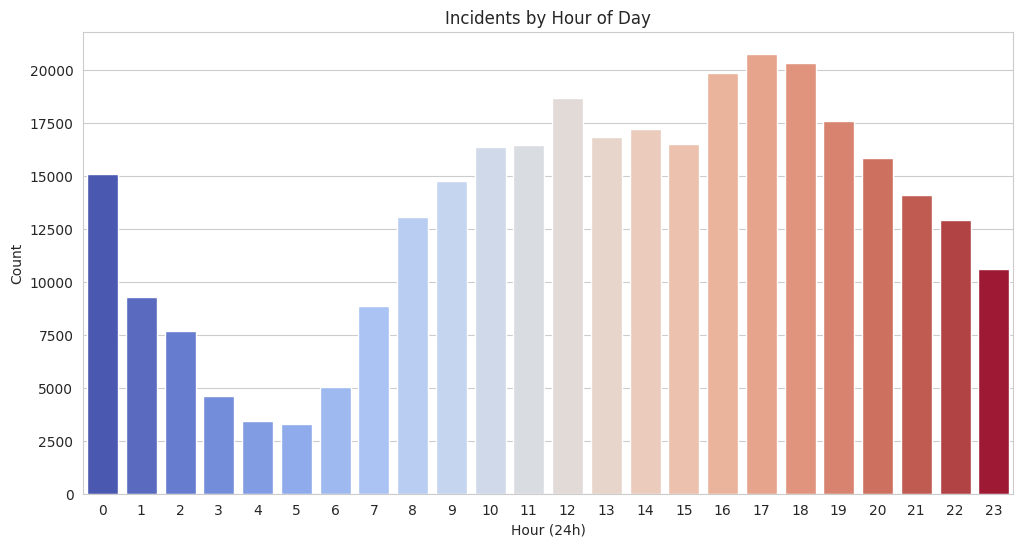

In [20]:
# Crimes by hour of day
hourly_counts = df['HOUR'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, hue=hourly_counts.index, palette='coolwarm', legend=False)
plt.title('Incidents by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Count')
plt.show()

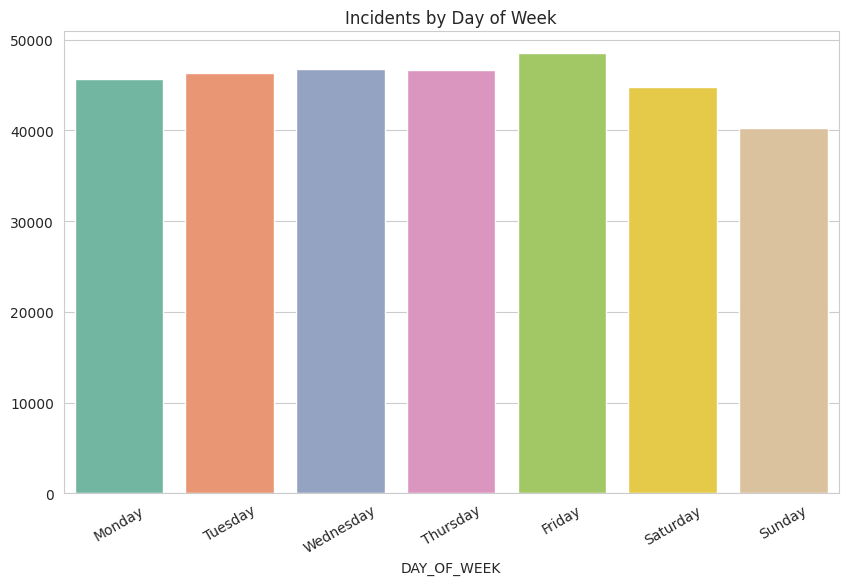

In [21]:
# Crimes by day of week
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['DAY_OF_WEEK'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, hue=weekday_counts.index, palette='Set2', legend=False)
plt.title('Incidents by Day of Week')
plt.xticks(rotation=30)
plt.show()

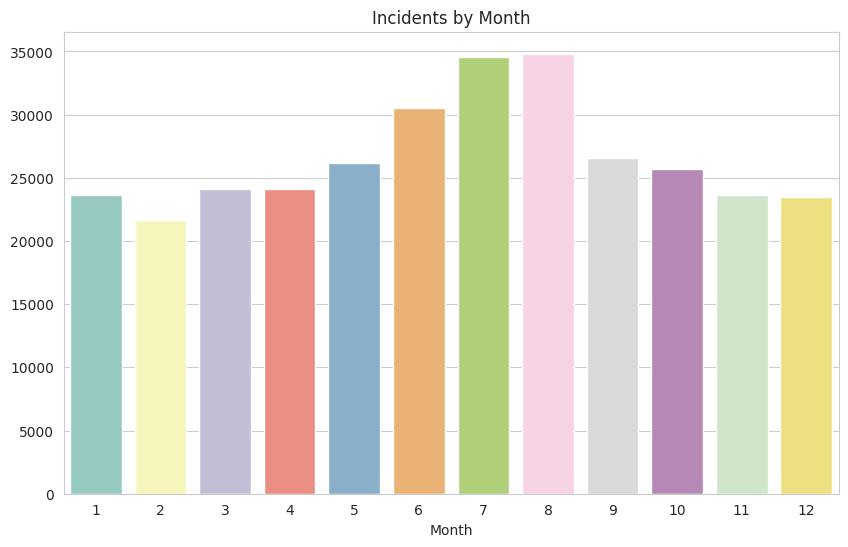

In [22]:
# Crimes by month
monthly_counts = df['MONTH'].value_counts().sort_index()

plt.figure(figsize=(10,6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, hue=monthly_counts.index, palette='Set3', legend=False)
plt.title('Incidents by Month')
plt.xlabel('Month')
plt.show()

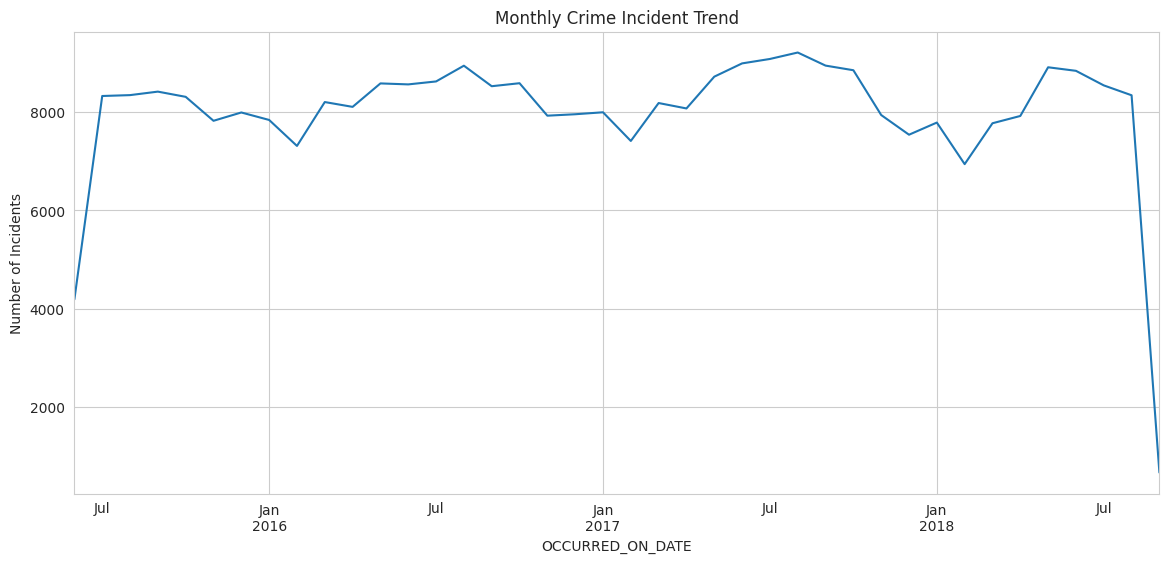

In [23]:
# Crime trend over years - monthly resample
monthly_trend = df.set_index('OCCURRED_ON_DATE').resample('ME').size()

plt.figure(figsize=(14,6))
monthly_trend.plot()
plt.title('Monthly Crime Incident Trend')
plt.ylabel('Number of Incidents')
plt.show()

In [24]:
# Arrest rate by hour - Note: this dataset may not have an ARREST column
# Check first:
'ARREST' in df.columns

False

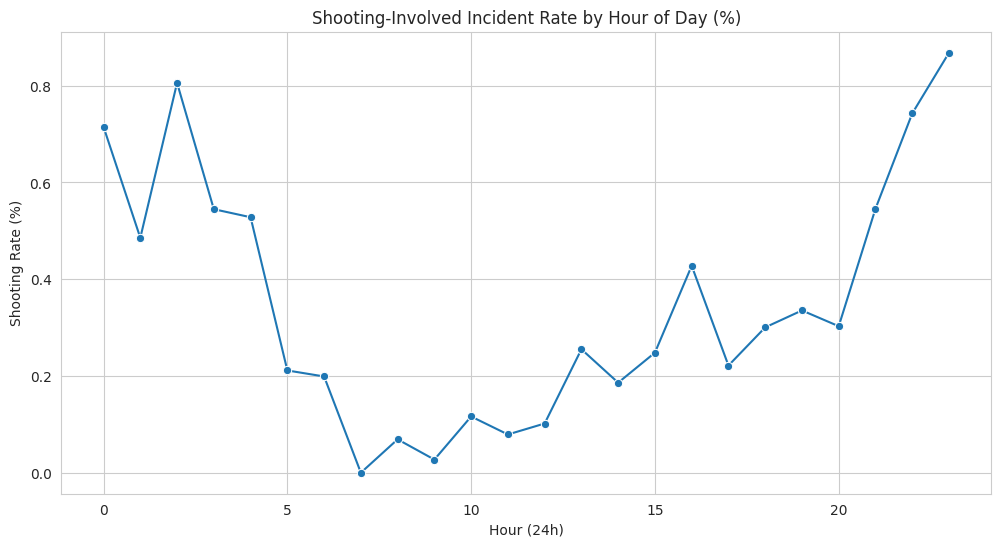

In [25]:
# If ARREST column doesn't exist, use SHOOTING rate by hour instead as a proxy analysis
shooting_by_hour = df.groupby('HOUR')['SHOOTING'].apply(lambda x: (x == 'Y').mean() * 100)

plt.figure(figsize=(12,6))
sns.lineplot(x=shooting_by_hour.index, y=shooting_by_hour.values, marker='o')
plt.title('Shooting-Involved Incident Rate by Hour of Day (%)')
plt.xlabel('Hour (24h)')
plt.ylabel('Shooting Rate (%)')
plt.show()

**5. Geospatial + Multivariate Analysis**

In [26]:
# Prepare geospatial subset - drop missing coordinates
geo_df = df.dropna(subset=['Lat', 'Long'])
geo_df.shape

(298307, 18)

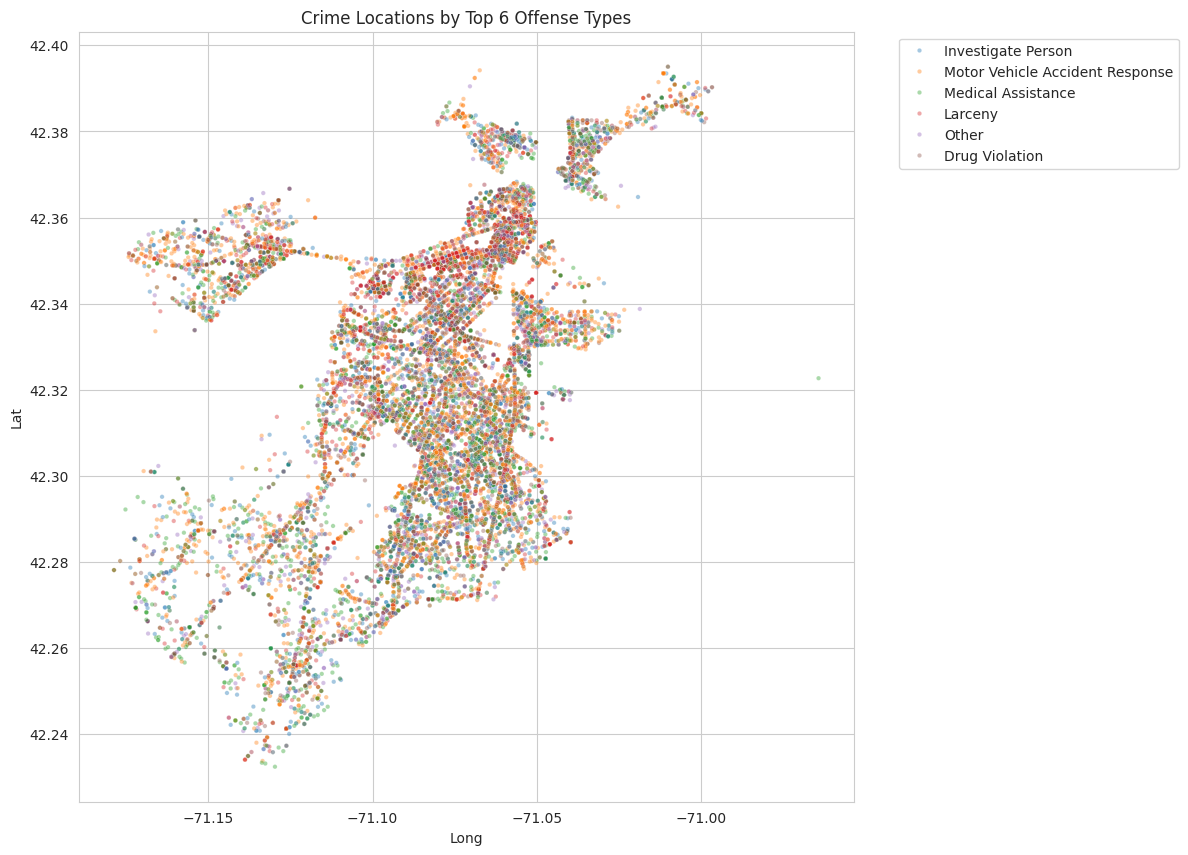

In [27]:
# Crime locations colored by top 6 offense types
top6_offenses = df['OFFENSE_CODE_GROUP'].value_counts().head(6).index
geo_subset = geo_df[geo_df['OFFENSE_CODE_GROUP'].isin(top6_offenses)]

plt.figure(figsize=(10,10))
sns.scatterplot(data=geo_subset.sample(min(20000, len(geo_subset)), random_state=42),
                 x='Long', y='Lat', hue='OFFENSE_CODE_GROUP', alpha=0.4, s=10)
plt.title('Crime Locations by Top 6 Offense Types')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

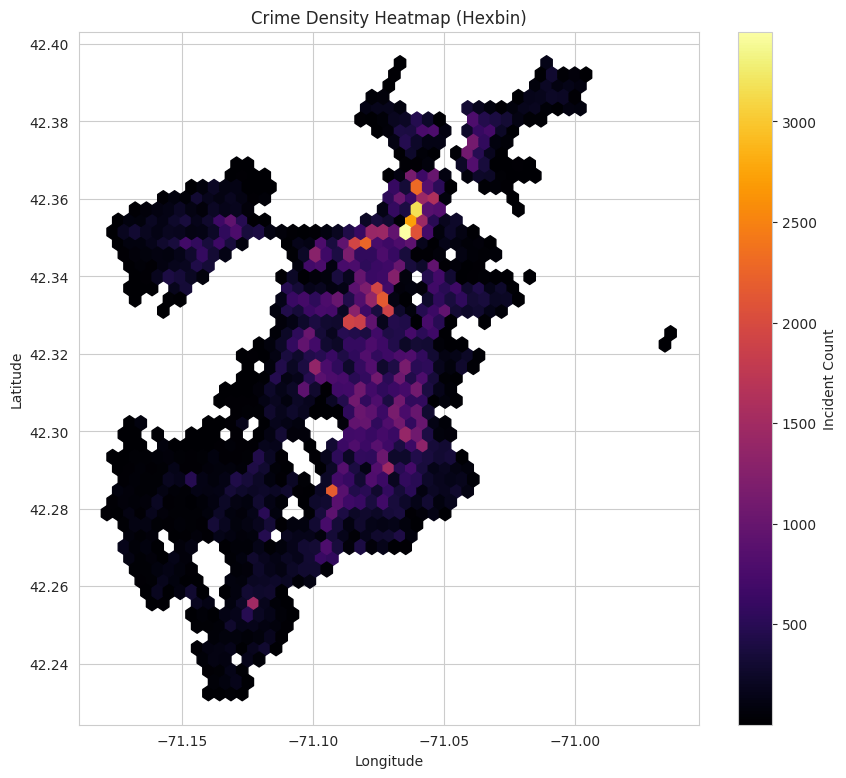

In [28]:
# Density-style hexbin plot of crime locations
plt.figure(figsize=(10,9))
plt.hexbin(geo_df['Long'], geo_df['Lat'], gridsize=50, cmap='inferno', mincnt=1)
plt.colorbar(label='Incident Count')
plt.title('Crime Density Heatmap (Hexbin)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

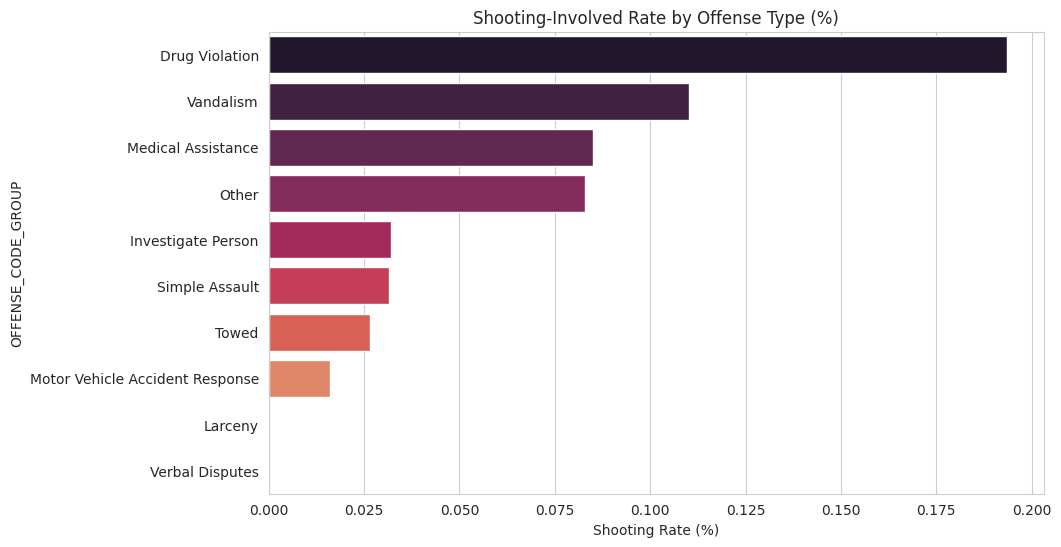

In [29]:
# Shooting-involved rate by offense type (top 10 offenses)
top10_offenses = df['OFFENSE_CODE_GROUP'].value_counts().head(10).index
offense_shooting = df[df['OFFENSE_CODE_GROUP'].isin(top10_offenses)].groupby('OFFENSE_CODE_GROUP')['SHOOTING'].apply(
    lambda x: (x == 'Y').mean() * 100).sort_values(ascending=False)

sns.barplot(x=offense_shooting.values, y=offense_shooting.index, hue=offense_shooting.index, palette='rocket', legend=False)
plt.title('Shooting-Involved Rate by Offense Type (%)')
plt.xlabel('Shooting Rate (%)')
plt.show()

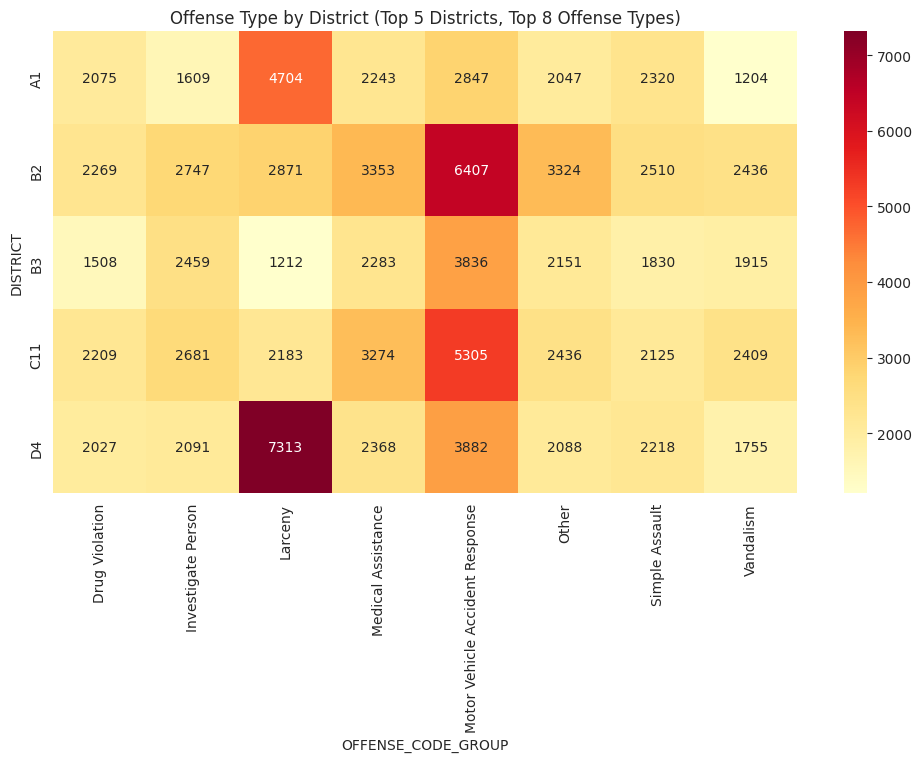

In [30]:
# Offense type breakdown by district (top 5 districts, top 8 offense types)
top5_districts = df['DISTRICT'].value_counts().head(5).index
top8_offenses = df['OFFENSE_CODE_GROUP'].value_counts().head(8).index

heat_data = df[(df['DISTRICT'].isin(top5_districts)) & (df['OFFENSE_CODE_GROUP'].isin(top8_offenses))]
pivot = pd.crosstab(heat_data['DISTRICT'], heat_data['OFFENSE_CODE_GROUP'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Offense Type by District (Top 5 Districts, Top 8 Offense Types)')
plt.show()

**6. Insights Summary**

## Key Insights

- [Offense type, e.g., Motor Vehicle Accident Response or Larceny] is the most frequently reported incident type in Boston.
- Incidents peak during [hour range] hours, with a noticeable dip overnight/early morning — matches typical activity patterns.
- [Day of week] sees the highest incident volume, while [day] sees the lowest.
- Shooting-involved incidents are concentrated in [offense types/time of day] — a small share of total incidents but a critical safety signal.
- District [X] has the highest incident count, and the offense heatmap shows it's driven primarily by [offense type].
- The density hexbin map highlights [downtown/specific area] as a hotspot for reported incidents.
- Monthly trend shows [seasonal increase in summer / relatively stable pattern] over the recorded years.
- [Add 1-2 more insights specific to what you observed]